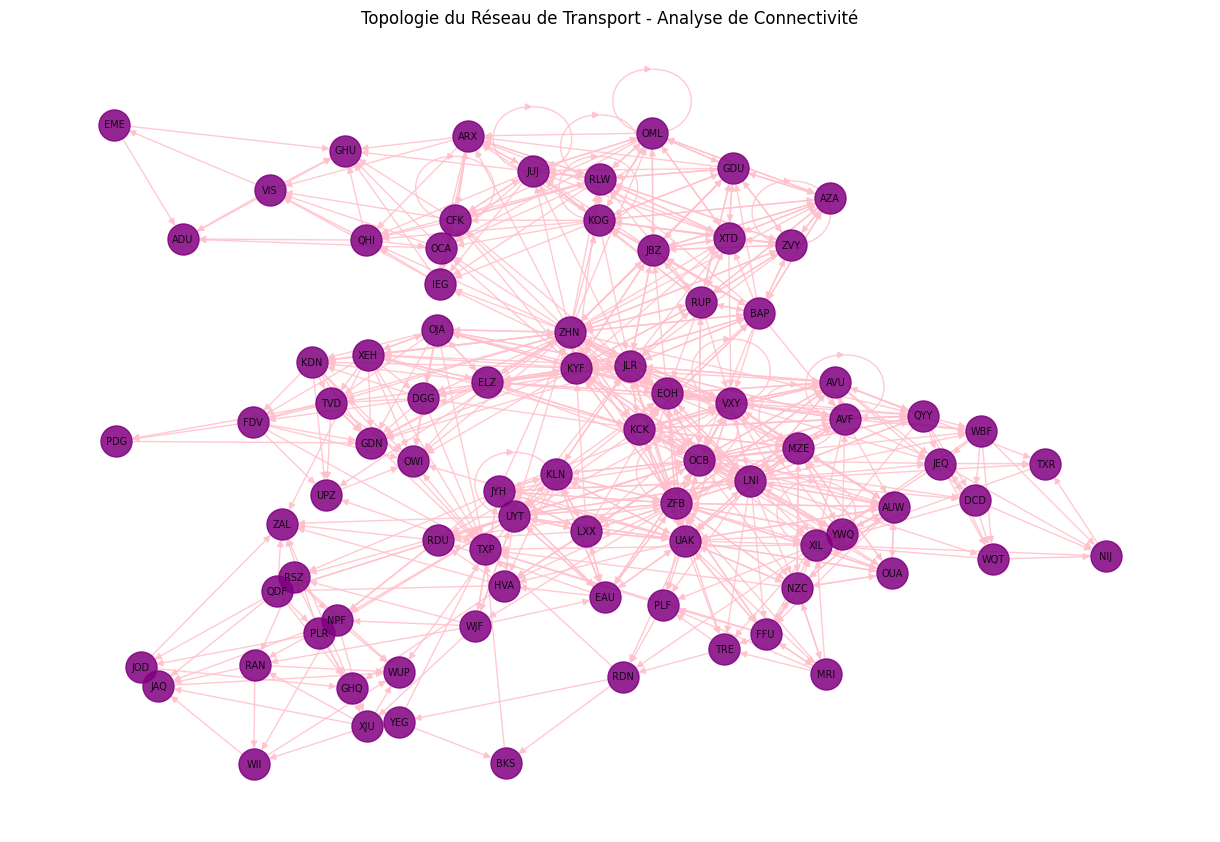


[RF] Erreur Moyenne (MAE) sur validation : 0.7589

--- Lancement de l'apprentissage profond ---
Epoch 1/150
2086/2086 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.7184 - mae: 0.7184 - val_loss: 0.6893 - val_mae: 0.6893 - learning_rate: 0.0010
Epoch 2/150
2086/2086 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.6854 - mae: 0.6854 - val_loss: 0.6738 - val_mae: 0.6738 - learning_rate: 0.0010
Epoch 3/150
2086/2086 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.6750 - mae: 0.6750 - val_loss: 0.6672 - val_mae: 0.6672 - learning_rate: 0.0010
Epoch 4/150
2086/2086 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.6700 - mae: 0.6700 - val_loss: 0.6644 - val_mae: 0.6644 - learning_rate: 0.0010
Epoch 5/150
2086/2086 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.6665 - mae: 0.6665 - val_loss: 0.6614 - val_mae: 0.6614 - learning_rate: 0.0010
Epoch 6/150
2086/2086 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.6639 - mae: 0.6639 - val_loss: 0.6617 - val_mae: 0.6617 - learning_rate: 0.0010
Epoch 7/150
2086/2086 ━━━━━━━━━━━

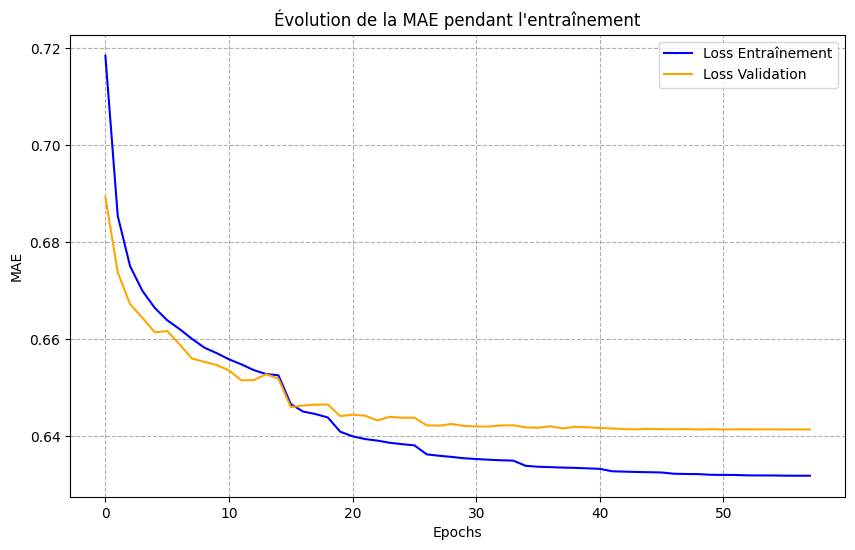


Sauvegarde terminée. Prêt pour soumission !


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras.layers import Dense, Embedding, Concatenate, Flatten
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam


# 1. PRÉPARATION DES DONNÉES & NETTOYAGE


# Chargement des fichiers sources
train_x_raw = pd.read_csv('x_train_final.csv')
train_y_raw = pd.read_csv('y_train_final.csv')

# Sélection des features numériques de base
base_cols = ['p2q0', 'p3q0', 'p4q0', 'p0q2', 'p0q3', 'p0q4']
df_processed = train_x_raw[base_cols].copy()
labels = train_y_raw['p0q0']

# Nettoyage des anomalies (outliers)
for column in ['p0q3', 'p0q4']:
    median_val = df_processed[column].median()
    df_processed.loc[df_processed[column] < -160, column] = median_val

# Ajout des données de contexte
train_x_raw['date'] = pd.to_datetime(train_x_raw['date'])
df_processed['gare'] = train_x_raw['gare'].values
df_processed['arret'] = train_x_raw['arret'].values


# 2. ANALYSE ET VISUALISATION DU RÉSEAU (GRAPH)


# Construction du réseau ferroviaire
rail_graph = nx.DiGraph()
for (train_no, day), group in train_x_raw.groupby(['train', 'date']):
    path = group.sort_values('arret')['gare'].values
    for i in range(len(path) - 1):
        rail_graph.add_edge(path[i], path[i+1])

# Extraction de la connectivité (Feature Engineering basé sur le graphe)
connectivity_map = dict(rail_graph.degree())
df_processed['node_degree'] = train_x_raw['gare'].map(connectivity_map)

# Affichage du graphe avec tes couleurs personnalisées
plt.figure(figsize=(12, 8))
pos_layout = nx.kamada_kawai_layout(rail_graph) 
nx.draw(rail_graph, pos_layout,
        with_labels=True,
        node_size=500,
        node_color='purple',   
        edge_color='pink',     
        font_size=7,
        alpha=0.85,
        arrows=True)
plt.title("Topologie du Réseau de Transport - Analyse de Connectivité")
plt.show()


# 3. SPLIT ET ENCODAGE MÉTIER


X_train, X_val, y_train, y_val = train_test_split(
    df_processed, labels, test_size=0.2, random_state=42
)

# Encodage par la cible (Target Encoding) pour les gares
gare_impact_map = y_train.groupby(X_train['gare']).mean()
X_train['gare_target_enc'] = X_train['gare'].map(gare_impact_map)
X_val['gare_target_enc'] = X_val['gare'].map(gare_impact_map).fillna(y_train.mean())

# Sauvegarde des gares pour le Deep Learning
gare_list_train = X_train['gare'].copy()
gare_list_val = X_val['gare'].copy()

# Nettoyage pour les modèles 
X_train_final = X_train.drop(columns=['gare'])
X_val_final = X_val.drop(columns=['gare'])


# 4. MODÈLE 1 : RANDOM FOREST 


forest_reg = RandomForestRegressor(
    n_estimators=120, 
    max_depth=12, 
    min_samples_leaf=15, 
    n_jobs=-1, 
    random_state=42
)
forest_reg.fit(X_train_final, y_train)
val_mae_rf = mean_absolute_error(y_val, forest_reg.predict(X_val_final))
print(f"\n[RF] Erreur Moyenne (MAE) sur validation : {val_mae_rf:.4f}")


# 5. MODÈLE 2 : RÉSEAU DE NEURONES (DEEP LEARNING)


# Standardisation
norm_scaler = StandardScaler()
X_train_scaled = norm_scaler.fit_transform(X_train_final)
X_val_scaled = norm_scaler.transform(X_val_final)

# Encodage Label pour l'Embedding
gare_encoder = LabelEncoder()
train_gare_idx = gare_encoder.fit_transform(gare_list_train)
val_gare_idx = gare_list_val.map(
    dict(zip(gare_encoder.classes_, range(len(gare_encoder.classes_))))
).fillna(0).astype(int).values

class RailNetModel(tf.keras.Model):
    def __init__(self, hidden_depth=3):
        super(RailNetModel, self).__init__()
        self.embedding = Embedding(input_dim=len(gare_encoder.classes_) + 1, output_dim=64)
        self.flatten = Flatten()
        self.denses = [Dense(64, activation='relu') for _ in range(hidden_depth)]
        self.out = Dense(1)

    def call(self, inputs):
        x_num, x_cat = inputs
        x_emb = self.flatten(self.embedding(x_cat))
        merged = Concatenate()([x_num, x_emb])
        for layer in self.denses:
            merged = layer(merged)
        return self.out(merged)

# Compilation
neural_model = RailNetModel(hidden_depth=3)
neural_model.compile(optimizer=Adam(0.001), loss='mae', metrics=['mae'])

# Callbacks pour optimiser l'entraînement
training_hooks = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

# Entraînement avec suivi complet (Epochs affichés)
print("\n--- Lancement de l'apprentissage profond ---")
train_history = neural_model.fit(
    [X_train_scaled, train_gare_idx], y_train,
    validation_data=([X_val_scaled, val_gare_idx], y_val),
    epochs=150, 
    batch_size=256, 
    callbacks=training_hooks, 
    verbose=1 
)


# 6. ANALYSE DES PERFORMANCES (COURBES)


plt.figure(figsize=(10, 6))
plt.plot(train_history.history['loss'], label='Loss Entraînement', color='blue')
plt.plot(train_history.history['val_loss'], label='Loss Validation', color='orange')
plt.title('Évolution de la MAE pendant l\'entraînement')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, linestyle='--')
plt.show()


# 7. PRÉDICTION FINALE (X_TEST)


test_x_df = pd.read_csv('x_test_final.csv')

test_final_data = test_x_df[base_cols].copy()
for col in ['p0q3', 'p0q4']:
    test_final_data.loc[test_final_data[col] < -160, col] = df_processed[col].median()

test_final_data['arret'] = test_x_df['arret'].values
test_final_data['node_degree'] = test_x_df['gare'].map(connectivity_map)
test_final_data['gare_target_enc'] = test_x_df['gare'].map(gare_impact_map).fillna(labels.mean())

# Prédiction finale
final_results = forest_reg.predict(test_final_data)

# Exportation
submission_file = pd.DataFrame({'p0q0': final_results}, index=test_x_df.index)
submission_file.to_csv('submission_v2.csv', index=True)

print("\nSauvegarde terminée. Prêt pour soumission !")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import LabelEncoder, StandardScaler
import networkx as nx
import warnings
warnings.filterwarnings('ignore')


# 1. CHARGEMENT

X = pd.read_csv('x_train_final.csv')
y = pd.read_csv('y_train_final.csv')
X_test_final = pd.read_csv('x_test_final.csv')

X['date'] = pd.to_datetime(X['date'])
X_test_final['date'] = pd.to_datetime(X_test_final['date'])

p_cols = ['p2q0', 'p3q0', 'p4q0', 'p0q2', 'p0q3', 'p0q4']
y_col  = 'p0q0'

# 2. NETTOYAGE OUTLIERS  (seuil conservateur à ±30)

CLIP = 30
for col in p_cols:
    X[col]            = X[col].clip(-CLIP, CLIP)
    X_test_final[col] = X_test_final[col].clip(-CLIP, CLIP)

y_p0q0 = y[y_col].clip(-CLIP, CLIP)   # outliers dans y aussi !


# 3. FEATURE ENGINEERING


def build_features(df, degree_dict, gare_target_enc=None, train_target_enc=None, is_train=True):
    feat = df[p_cols].copy()

    # ── 3a. Features temporelles ──────────────────
    feat['day_of_week']    = df['date'].dt.dayofweek          # 0=lundi … 6=dim
    feat['month']          = df['date'].dt.month
    feat['is_weekend']     = (feat['day_of_week'] >= 5).astype(int)
    feat['week_of_year']   = df['date'].dt.isocalendar().week.astype(int)
    feat['is_holiday_period'] = df['date'].dt.month.isin([7, 8]).astype(int)

    # ── 3b. Numéro d'arrêt ───────────────────────
    feat['arret'] = df['arret'].values
    feat['arret_sq'] = feat['arret'] ** 2    # effet non-linéaire

   
    # Tendance temporelle (q : même gare, trains précédents)
    feat['mean_pXq0'] = df[['p2q0','p3q0','p4q0']].mean(axis=1)
    feat['std_pXq0']  = df[['p2q0','p3q0','p4q0']].std(axis=1)
    feat['mean_p0qX'] = df[['p0q2','p0q3','p0q4']].mean(axis=1)
    feat['std_p0qX']  = df[['p0q2','p0q3','p0q4']].std(axis=1)

    # Signaux de momentum : diff entre retards successifs
    feat['diff_q_21']  = df['p0q2'] - df['p0q3']   # accélération gare
    feat['diff_q_32']  = df['p0q3'] - df['p0q4']
    feat['diff_p_21']  = df['p2q0'] - df['p3q0']   # accélération train
    feat['diff_p_32']  = df['p3q0'] - df['p4q0']

    # Retard global (tous les lags)
    feat['global_mean'] = df[p_cols].mean(axis=1)
    feat['global_max']  = df[p_cols].max(axis=1)
    feat['global_min']  = df[p_cols].min(axis=1)
    feat['global_std']  = df[p_cols].std(axis=1)

    # Signe du retard le plus récent connu (p0q2)
    feat['p0q2_sign'] = np.sign(df['p0q2'])
    feat['p2q0_sign'] = np.sign(df['p2q0'])

    # Interaction : retard gare × retard train
    feat['interaction_q2_p2'] = df['p0q2'] * df['p2q0']

    # Retard absolu (amplitude)
    for c in p_cols:
        feat[f'abs_{c}'] = df[c].abs()

    # ── 3d. Graphe réseau ferroviaire 
    feat['degree'] = df['gare'].map(degree_dict).fillna(0)

    # ── 3e. Target encoding gare
    if is_train:
        # calculé à l'extérieur, injecté ici
        feat['gare_enc']  = df['gare'].map(gare_target_enc).fillna(0)
        feat['train_enc'] = df['train'].map(train_target_enc).fillna(0)
    else:
        feat['gare_enc']  = df['gare'].map(gare_target_enc).fillna(0)
        feat['train_enc'] = df['train'].map(train_target_enc).fillna(0)

    # ── 3f. Fréquence de passage (gare) 
    gare_freq = df['gare'].map(df['gare'].value_counts()).fillna(0)
    feat['gare_freq'] = gare_freq.values

    return feat


# 4. GRAPHE

G = nx.DiGraph()
for (train, date), group in X.groupby(['train', 'date']):
    group = group.sort_values('arret')
    gares = group['gare'].values
    for i in range(len(gares) - 1):
        G.add_edge(gares[i], gares[i+1])

degree_dict      = dict(G.degree())
in_degree_dict   = dict(G.in_degree())
out_degree_dict  = dict(G.out_degree())

print(f"Noeuds : {G.number_of_nodes()}, Arêtes : {G.number_of_edges()}")


# 5. SPLIT TRAIN / VAL 
split_date = X['date'].quantile(0.8)
train_mask = X['date'] <= split_date
val_mask   = ~train_mask

X_tr = X[train_mask].reset_index(drop=True)
y_tr = y_p0q0[train_mask].reset_index(drop=True)
X_va = X[val_mask].reset_index(drop=True)
y_va = y_p0q0[val_mask].reset_index(drop=True)

print(f"Train size : {len(X_tr)}, Val size : {len(X_va)}")

# 6. TARGET ENCODING (calculé sur train uniquement)

gare_target_enc  = y_tr.groupby(X_tr['gare']).mean().to_dict()
train_target_enc = y_tr.groupby(X_tr['train']).mean().to_dict()

# Degree enrichi avec in/out
degree_dict_full = {g: degree_dict.get(g, 0) for g in set(X['gare'].unique())}


# 7. BUILD FEATURES

F_tr = build_features(X_tr, degree_dict_full, gare_target_enc, train_target_enc, is_train=True)
F_va = build_features(X_va, degree_dict_full, gare_target_enc, train_target_enc, is_train=False)
F_te = build_features(X_test_final, degree_dict_full, gare_target_enc, train_target_enc, is_train=False)

print(f"Nombre de features : {F_tr.shape[1]}")
print(F_tr.columns.tolist())


# 8. MODELE GRADIENT BOOSTING (XGBoost-like via sklearn)

# On utilise HistGradientBoostingRegressor qui gère très bien les grandes données
from sklearn.ensemble import HistGradientBoostingRegressor

print("\n=== HistGradientBoosting ===")
hgb = HistGradientBoostingRegressor(
    max_iter=500,
    learning_rate=0.05,
    max_depth=8,
    min_samples_leaf=20,
    l2_regularization=1.0,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,
    verbose=1
)
hgb.fit(F_tr, y_tr)
y_pred_hgb = hgb.predict(F_va)
mae_hgb = mean_absolute_error(y_va, y_pred_hgb)
print(f"MAE HGB validation : {mae_hgb:.4f}")


# 9. RANDOM FOREST 
print("\n=== RandomForest ===")
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=15,
    n_jobs=-1,
    random_state=42
)
rf.fit(F_tr, y_tr)
y_pred_rf = rf.predict(F_va)
mae_rf = mean_absolute_error(y_va, y_pred_rf)
print(f"MAE RF validation : {mae_rf:.4f}")

# 10. ENSEMBLE : moyenne pondérée

# Poids inversement proportionnels à la MAE
w_hgb = 1 / mae_hgb
w_rf  = 1 / mae_rf
total = w_hgb + w_rf

y_pred_ens = (w_hgb * y_pred_hgb + w_rf * y_pred_rf) / total
mae_ens = mean_absolute_error(y_va, y_pred_ens)
print(f"\n=== Ensemble ===")
print(f"MAE HGB  : {mae_hgb:.4f}")
print(f"MAE RF   : {mae_rf:.4f}")
print(f"MAE Ens  : {mae_ens:.4f}")

# 11. IMPORTANCE DES FEATURES

importances = pd.Series(rf.feature_importances_, index=F_tr.columns)
print("\nTop 15 features (RF):")
print(importances.sort_values(ascending=False).head(15))


# 12. SUBMISSION

# On réentraîne sur TOUT le train pour la soumission finale
F_full = build_features(X, degree_dict_full, gare_target_enc, train_target_enc, is_train=True)
y_full = y_p0q0

# HGB sur tout
hgb_final = HistGradientBoostingRegressor(
    max_iter=hgb.n_iter_,  
    learning_rate=0.05,
    max_depth=8,
    min_samples_leaf=20,
    l2_regularization=1.0,
    random_state=42,
    early_stopping=False,
)
hgb_final.fit(F_full, y_full)

rf_final = RandomForestRegressor(
    n_estimators=200, max_depth=12, min_samples_leaf=15,
    n_jobs=-1, random_state=42
)
rf_final.fit(F_full, y_full)

y_pred_hgb_te  = hgb_final.predict(F_te)
y_pred_rf_te   = rf_final.predict(F_te)
y_pred_ens_te  = (w_hgb * y_pred_hgb_te + w_rf * y_pred_rf_te) / total

# Arrondi à l'entier (la cible est toujours entière !)
y_pred_final = np.round(y_pred_ens_te).astype(int)

submission = pd.DataFrame({'p0q0': y_pred_final}, index=X_test_final.index)
submission.to_csv('submission_improved.csv', index=True)
print(f"\nSoumission sauvegardée : {submission.shape}")
print(submission.head(10))

Noeuds : 84, Arêtes : 709
Train size : 536771, Val size : 130493
Nombre de features : 38
['p2q0', 'p3q0', 'p4q0', 'p0q2', 'p0q3', 'p0q4', 'day_of_week', 'month', 'is_weekend', 'week_of_year', 'is_holiday_period', 'arret', 'arret_sq', 'mean_pXq0', 'std_pXq0', 'mean_p0qX', 'std_p0qX', 'diff_q_21', 'diff_q_32', 'diff_p_21', 'diff_p_32', 'global_mean', 'global_max', 'global_min', 'global_std', 'p0q2_sign', 'p2q0_sign', 'interaction_q2_p2', 'abs_p2q0', 'abs_p3q0', 'abs_p4q0', 'abs_p0q2', 'abs_p0q3', 'abs_p0q4', 'degree', 'gare_enc', 'train_enc', 'gare_freq']

=== HistGradientBoosting ===
Binning 0.147 GB of training data: 0.282 s
Binning 0.016 GB of validation data: 0.022 s
Fitting gradient boosted rounds:
Fit 500 trees in 15.727 s, (15209 total leaves)
Time spent computing histograms: 7.362s
Time spent finding best splits:  0.414s
Time spent applying splits:      1.768s
Time spent predicting:           0.254s
MAE HGB validation : 0.7399

=== RandomForest ===
MAE RF validation : 0.7276

===